In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
data4 = pd.read_csv('BT4.313092302_satisfaction_level.csv', delimiter=",") 
data4.head()

,Repair_Time,Waiting_Time,Satisfaction_Level
0,2.5,1.0,4
1,3.0,1.2,3
2,4.2,1.5,2
3,2.8,0.8,4
4,5.0,2.0,2


In [4]:
X = data4[['Repair_Time','Waiting_Time']]  # Biến độc lập, cần đặt trong dấu [[]] để giữ dạng DataFrame
y = data4['Satisfaction_Level']  # Biến phụ thuộc


In [5]:
# Khởi tạo mô hình
model = LinearRegression()

# Huấn luyện mô hình
model.fit(X, y)

LinearRegression()

In [6]:
# Dự đoán giá trị Credit_Score dựa trên Income
y_pred = model.predict(X)

In [8]:
# Hệ số hồi quy (slope) và intercept
slopes = model.coef_  # Đây là một mảng chứa hệ số của các biến độc lập
intercept = model.intercept_

# Tính R-square
r_square = model.score(X, y)

# In phương trình hồi quy đầy đủ
print(f"Phương trình hồi quy: Satisfaction_Level = {slopes[0]:.4f} * Repair_Time + {slopes[1]:.4f} * Waiting_Time + {intercept:.4f}")
print(f"R-square: {r_square:.4f}")

Phương trình hồi quy: Satisfaction_Level = -0.9337 * Repair_Time + -0.4802 * Waiting_Time + 7.0957
R-square: 0.8507


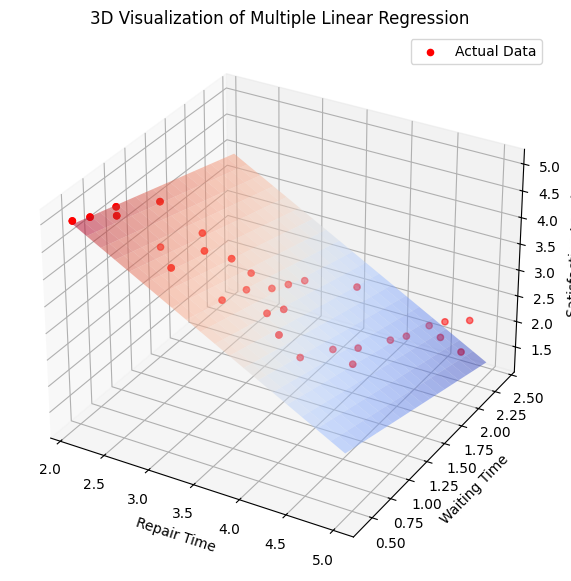

In [10]:
from mpl_toolkits.mplot3d import Axes3D
# Chuyển DataFrame X thành NumPy array
X_np = X.to_numpy()
# Tạo và huấn luyện mô hình
model = LinearRegression()
model.fit(X_np, y)

# Lấy hệ số hồi quy
slope1, slope2 = model.coef_
intercept = model.intercept_

# Tạo lưới điểm cho mặt phẳng hồi quy
repair_range = np.linspace(X_np[:, 0].min(), X_np[:, 0].max(), 20)
waiting_range = np.linspace(X_np[:, 1].min(), X_np[:, 1].max(), 20)
Repair_mesh, Waiting_mesh = np.meshgrid(repair_range, waiting_range)
Satisfaction_mesh = slope1 * Repair_mesh + slope2 * Waiting_mesh + intercept

# Tạo đồ thị 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Vẽ dữ liệu thực tế (các điểm)
ax.scatter(X_np[:, 0], X_np[:, 1], y, color='red', label='Actual Data')

# Vẽ mặt phẳng hồi quy
ax.plot_surface(Repair_mesh, Waiting_mesh, Satisfaction_mesh, alpha=0.5, cmap='coolwarm')

# Gán nhãn trục
ax.set_xlabel('Repair Time')
ax.set_ylabel('Waiting Time')
ax.set_zlabel('Satisfaction Level')
ax.set_title('3D Visualization of Multiple Linear Regression')

# Hiển thị legend
ax.legend()
plt.show()